# Prostate Cancer Prediction

## Importing Libraries and Loading Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
#https://www.kaggle.com/datasets/sajidsaifi/prostate-cancer
pc=pd.read_csv("Prostate_Cancer.csv")

In [3]:
pc.head()

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059


## Pre-processing and Exploratory Data Analysis

In [4]:
pc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   diagnosis_result   100 non-null    object 
 2   radius             100 non-null    int64  
 3   texture            100 non-null    int64  
 4   perimeter          100 non-null    int64  
 5   area               100 non-null    int64  
 6   smoothness         100 non-null    float64
 7   compactness        100 non-null    float64
 8   symmetry           100 non-null    float64
 9   fractal_dimension  100 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB


In [5]:
pc.isnull().sum()

id                   0
diagnosis_result     0
radius               0
texture              0
perimeter            0
area                 0
smoothness           0
compactness          0
symmetry             0
fractal_dimension    0
dtype: int64

In [6]:
pc.duplicated().sum()

0

In [7]:
#dropping irrelevant columns
pc.drop("id", axis=1, inplace=True)
pc.head()

,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,M,23,12,151,954,0.143,0.278,0.242,0.079
1,B,9,13,133,1326,0.143,0.079,0.181,0.057
2,M,21,27,130,1203,0.125,0.160,0.207,0.060
3,M,14,16,78,386,0.070,0.284,0.260,0.097
4,M,9,19,135,1297,0.141,0.133,0.181,0.059


## Data Visualization and Encoding

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
#set theme
sns.set_theme(palette="Set2")

<Axes: xlabel='diagnosis_result', ylabel='count'>

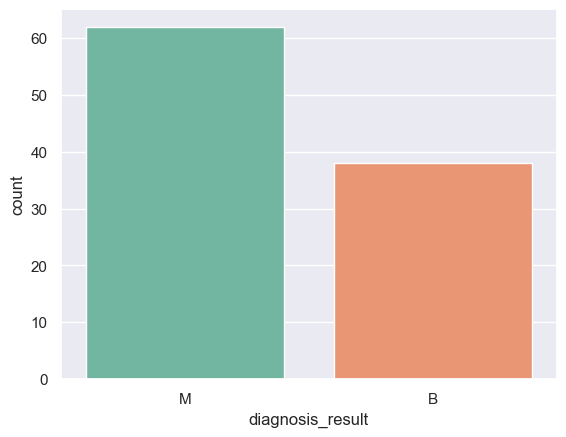

In [10]:
#countplot
sns.countplot(pc, x="diagnosis_result", hue="diagnosis_result")

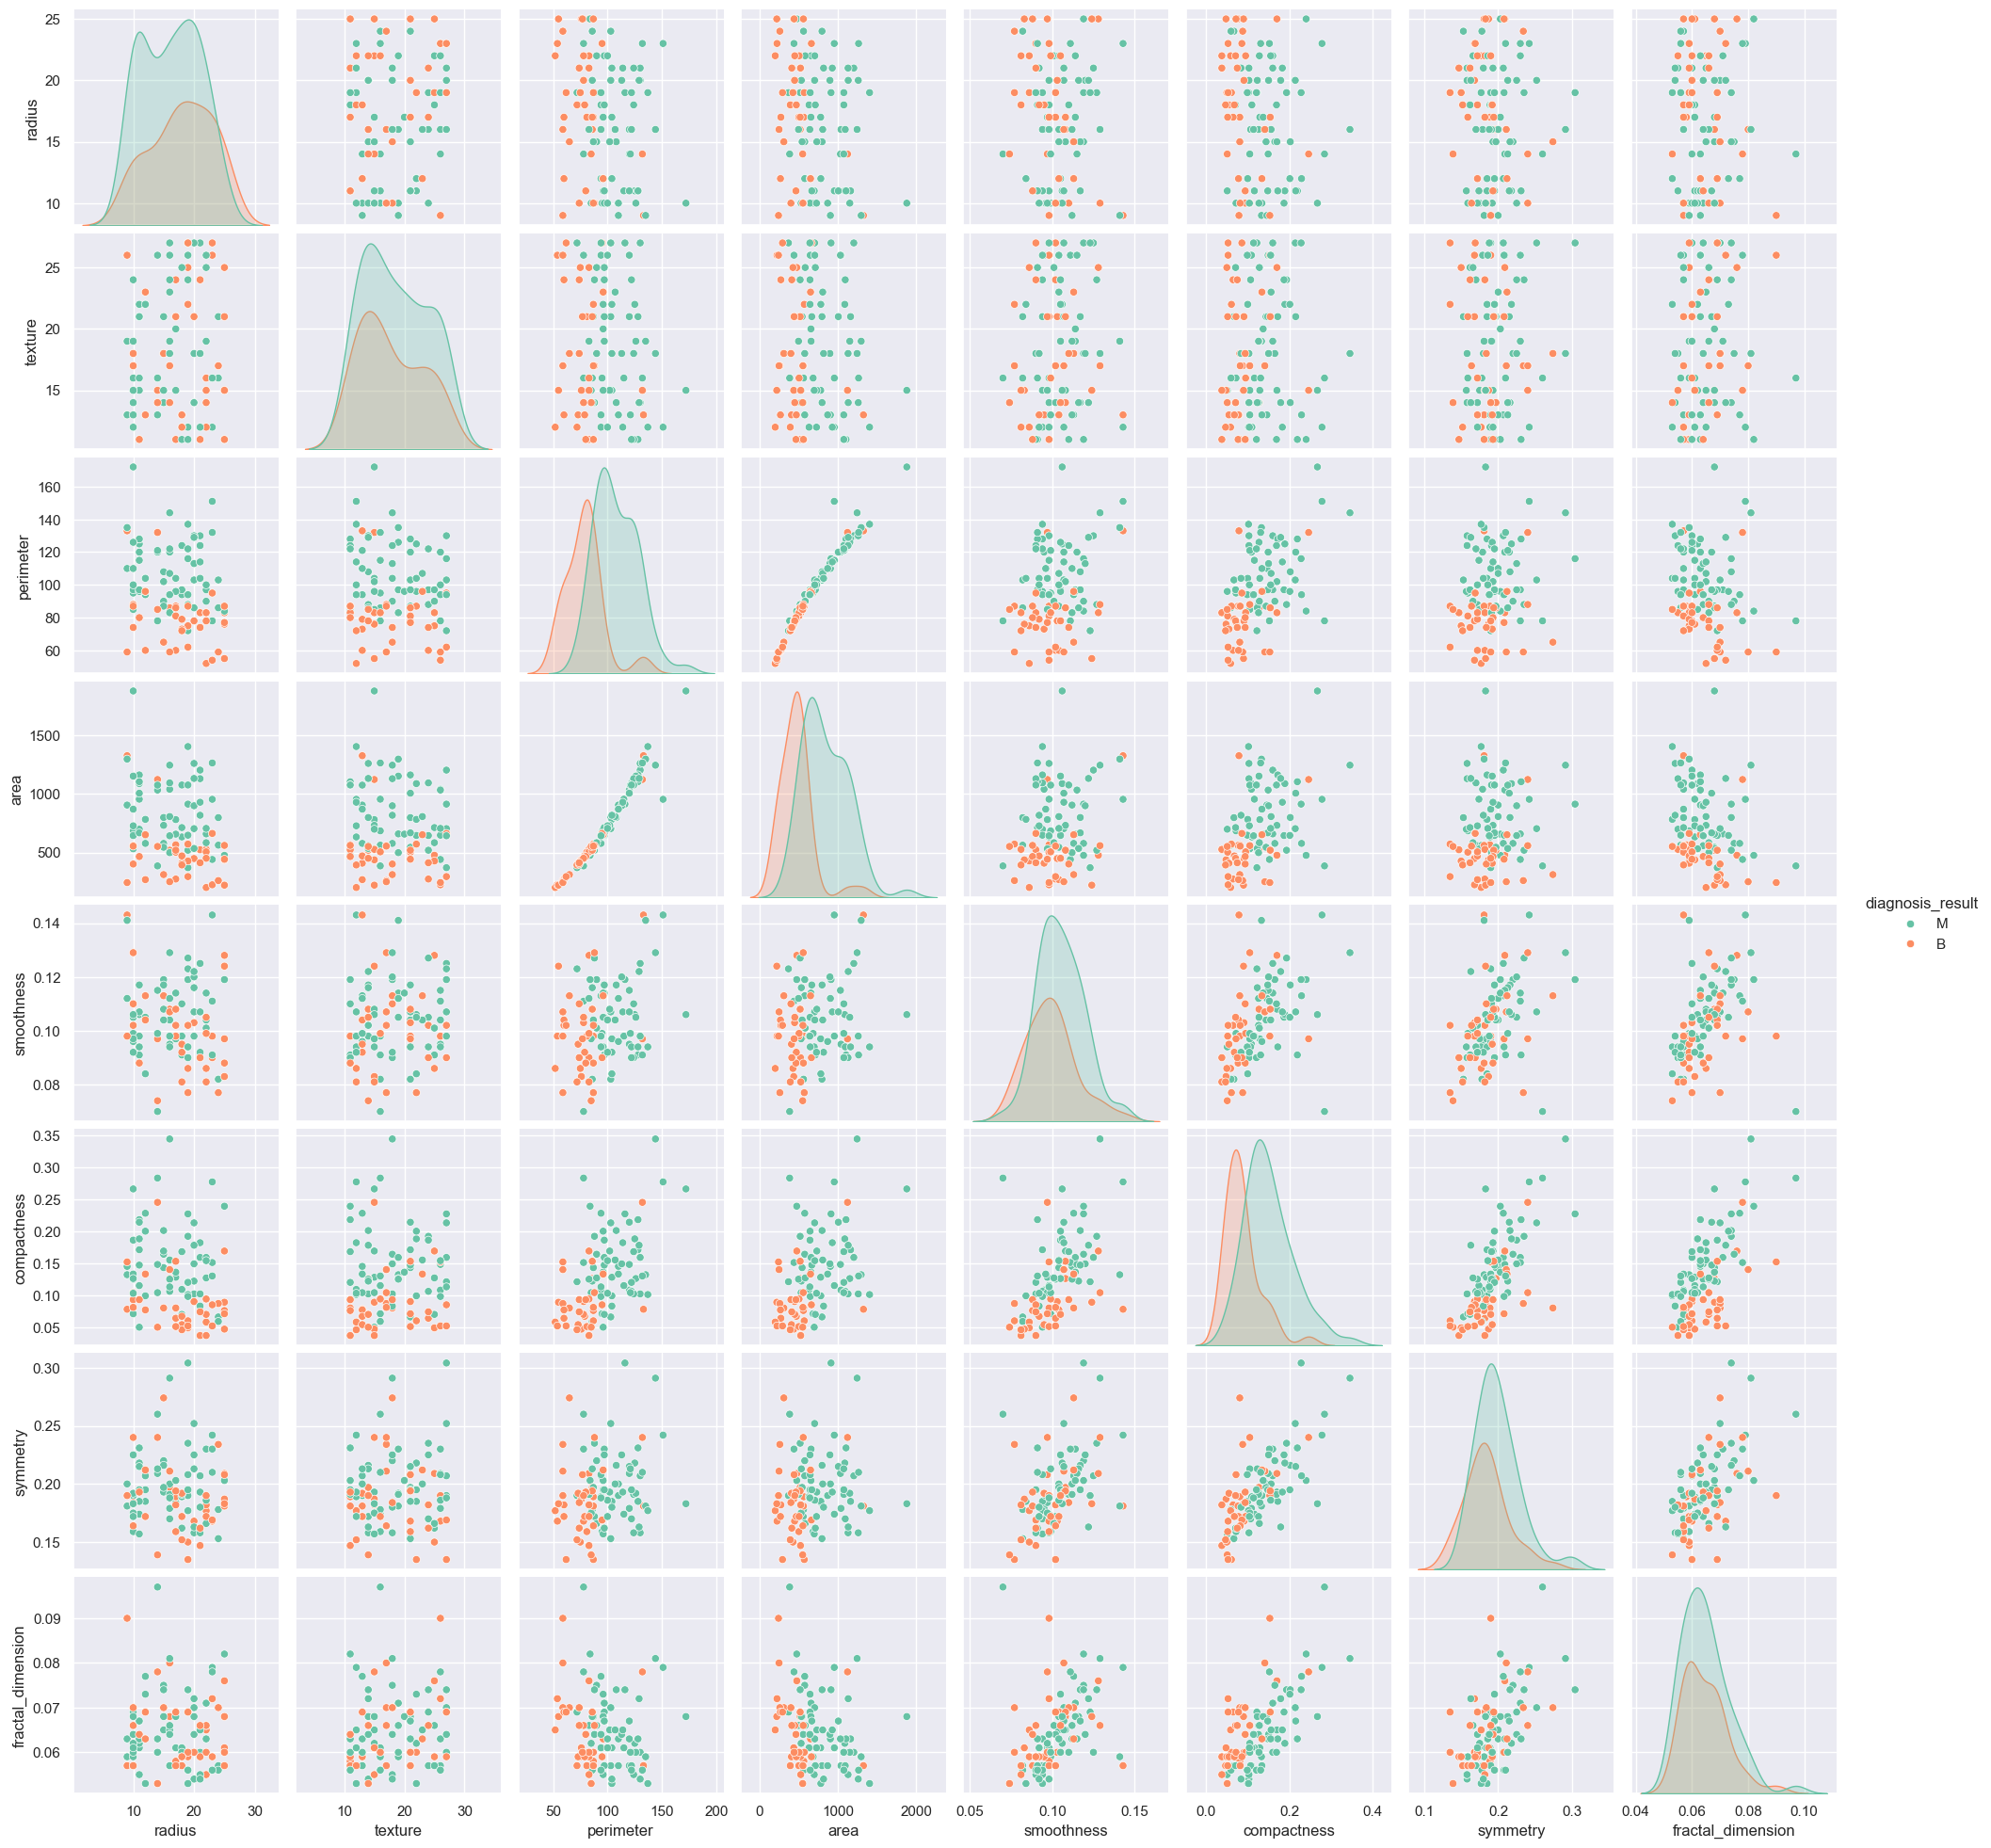

In [11]:
#pairplot
sns.pairplot(pc, hue="diagnosis_result")

## Preparing Data Before Training

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [13]:
#labelling target 
le=LabelEncoder()
pc["diagnosis_result"]=le.fit_transform(pc["diagnosis_result"])

for i, x in enumerate(le.classes_):
    print(f"{i}, {x}")

0, B
1, M


In [14]:
##select features(X) and target(y)
y=pc["diagnosis_result"]
X=pc.drop("diagnosis_result", axis=1)

In [15]:
#scaling data 
ss=StandardScaler()
X_scaled=ss.fit_transform(X)

#splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.7, random_state=42)

## Model Training and Performance Assesing

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_auc_score, roc_curve

In [17]:
#model building
models={
    "LogisticRegression": LogisticRegression(),
    "DecisionTreeClassifier": DecisionTreeClassifier(max_depth=3),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, max_depth=3),
    "SVM": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier()
}

LogisticRegression
Accuracy Score: 0.8333333333333334
Classification Report:               precision    recall  f1-score   support

           0       0.71      0.62      0.67         8
           1       0.87      0.91      0.89        22

    accuracy                           0.83        30
   macro avg       0.79      0.77      0.78        30
weighted avg       0.83      0.83      0.83        30

DecisionTreeClassifier
Accuracy Score: 0.7
Classification Report:               precision    recall  f1-score   support

           0       0.45      0.62      0.53         8
           1       0.84      0.73      0.78        22

    accuracy                           0.70        30
   macro avg       0.65      0.68      0.65        30
weighted avg       0.74      0.70      0.71        30

RandomForestClassifier
Accuracy Score: 0.7666666666666667
Classification Report:               precision    recall  f1-score   support

           0       0.56      0.62      0.59         8
           1 

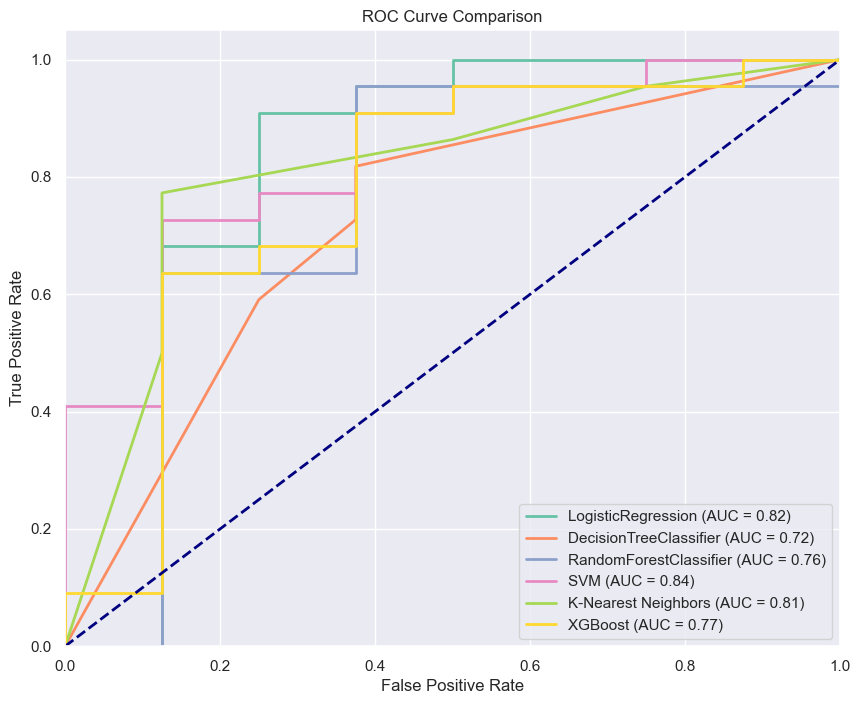

In [18]:
roc_auc_scores = {}

#plot the ROC curves
plt.figure(figsize=(10, 8))

for model_name, model in models.items():

    #model training
    model.fit(X_train, y_train)

    #predict X_test
    y_pred = model.predict(X_test)
    
    #performance metrics
    print(f"{model_name}")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
    print(f"Classification Report: {classification_report(y_test, y_pred)}")

    #predict the probabilities
    y_probs = model.predict_proba(X_test)[:, 1]
    
    #calculate the AUC - ROC score
    roc_auc = roc_auc_score(y_test, y_probs)
    roc_auc_scores[model_name] = roc_auc
    
    #compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    
    #plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

#plot random prediction line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

#customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()